# Разведочный анализ данных (EDA) — интернет-магазин электроники

Ноутбук отвечает на ключевые бизнес-вопросы по очищенным данным
(`data/processed/`, звёздная схема в `data/ecommerce.db`):

1. Как меняется выручка во времени?
2. Какие товары и категории приносят больше всего денег?
3. Какие сегменты клиентов (RFM) наиболее ценны?
4. Насколько хорошо удерживаются клиенты (cohort retention)?
5. Какие маркетинговые каналы окупаются лучше всего (ROAS)?

Графики сохраняются в `reports/figures/` и используются в главном README.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(ROOT / "data" / "ecommerce.db")

def q(sql):
    return pd.read_sql(sql, conn)

pd.options.display.float_format = "{:,.2f}".format

## 1. Динамика выручки по месяцам

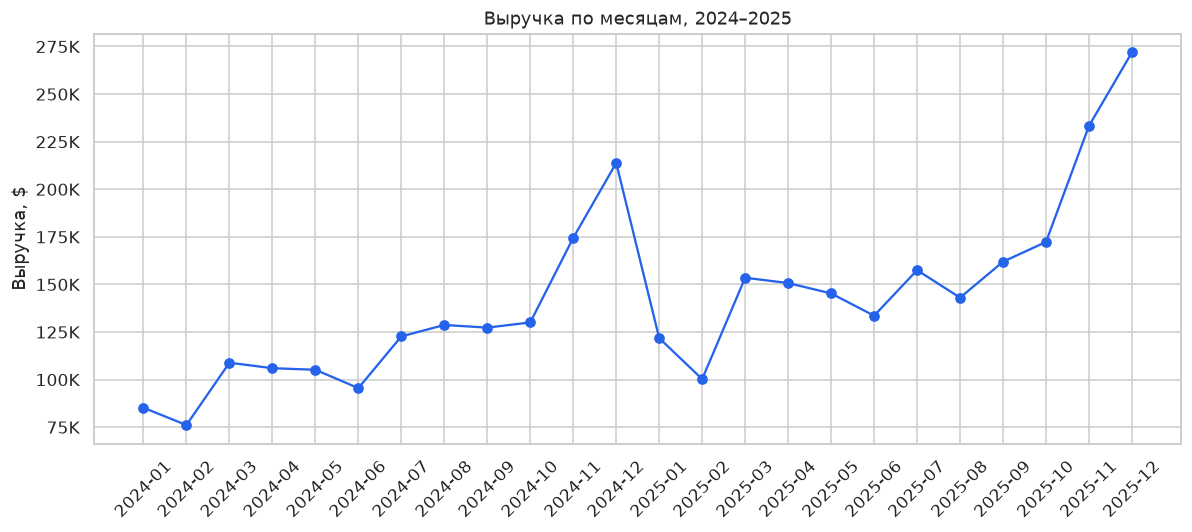

,year_month,revenue,orders_count
18,2025-07,"157,492.27",611
19,2025-08,"143,047.87",573
20,2025-09,"161,922.12",633
21,2025-10,"172,304.35",712
22,2025-11,"233,302.64",963
23,2025-12,"271,933.75",1097


In [2]:
monthly = q('''
    SELECT d.year_month,
           SUM(f.line_revenue) AS revenue,
           COUNT(DISTINCT f.order_id) AS orders_count
    FROM fact_orders f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.order_status = 'completed'
    GROUP BY d.year_month
    ORDER BY d.year_month
''')

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(monthly["year_month"], monthly["revenue"], marker="o", color="#2563eb", label="Выручка")
ax1.set_ylabel("Выручка, $")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Выручка по месяцам, 2024–2025")
plt.tight_layout()
plt.savefig(FIG_DIR / "monthly_revenue.png")
plt.show()

monthly.tail(6)

## 2. Топ-10 товаров и выручка по категориям

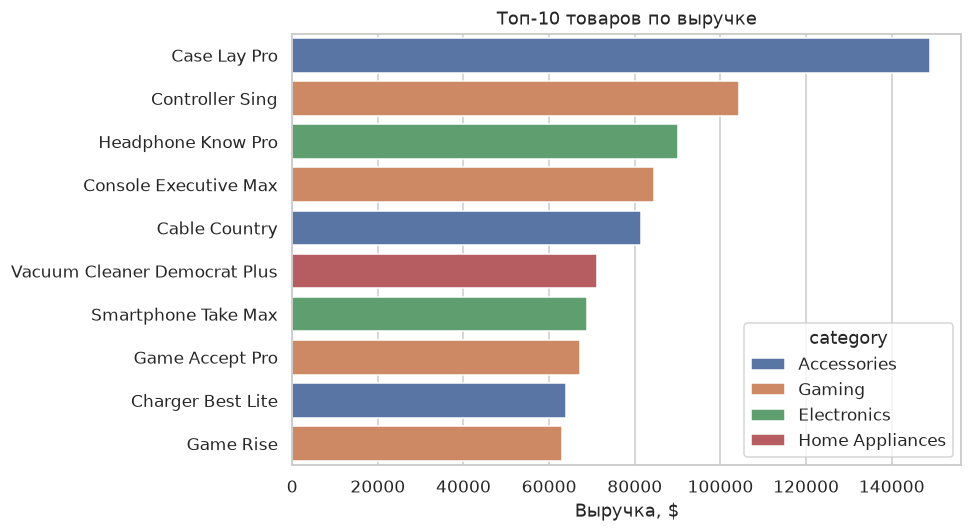

In [3]:
top_products = q('''
    SELECT p.product_name, p.category, SUM(f.quantity) AS units_sold,
           SUM(f.line_revenue) AS revenue
    FROM fact_orders f
    JOIN dim_products p ON f.product_id = p.product_id
    WHERE f.order_status = 'completed'
    GROUP BY p.product_id, p.product_name, p.category
    ORDER BY revenue DESC
    LIMIT 10
''')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_products, y="product_name", x="revenue", hue="category", dodge=False, ax=ax)
ax.set_title("Топ-10 товаров по выручке")
ax.set_xlabel("Выручка, $")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_products.png")
plt.show()

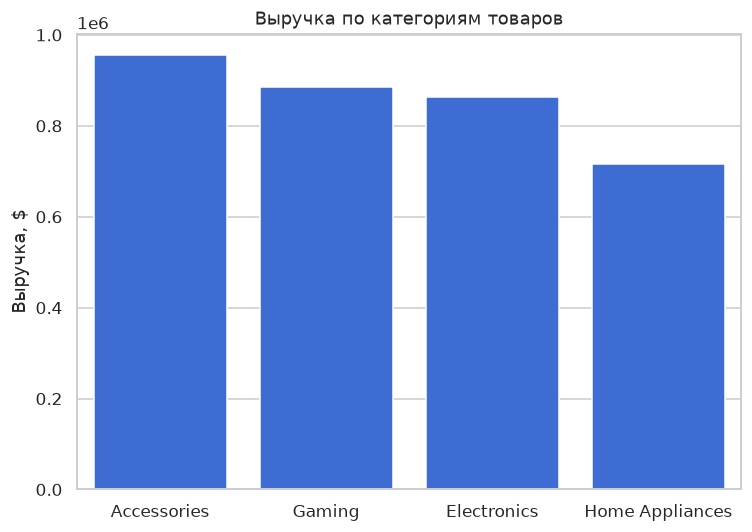

In [4]:
category_revenue = q('''
    SELECT p.category, SUM(f.line_revenue) AS revenue
    FROM fact_orders f
    JOIN dim_products p ON f.product_id = p.product_id
    WHERE f.order_status = 'completed'
    GROUP BY p.category
    ORDER BY revenue DESC
''')

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=category_revenue, x="category", y="revenue", ax=ax, color="#2563eb")
ax.set_title("Выручка по категориям товаров")
ax.set_ylabel("Выручка, $")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "category_revenue.png")
plt.show()

## 3. RFM-сегментация клиентов

Recency (давность последней покупки), Frequency (число заказов),
Monetary (сумма выручки) — считаем в pandas и делим на квартили (`qcut`).

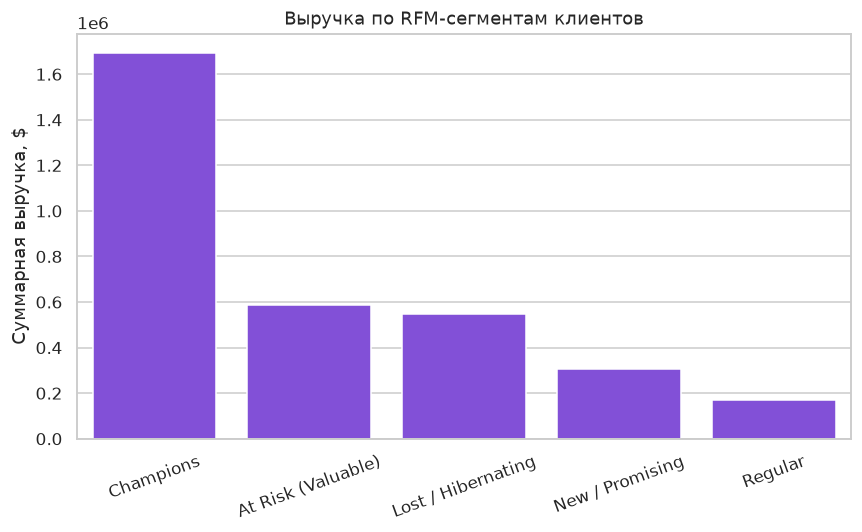

,customers,total_revenue,avg_orders,revenue_share_pct
segment,,,,
Champions,1590,"1,693,072.38",3.81,51.20
At Risk (Valuable),729,"588,204.62",2.68,17.80
Lost / Hibernating,2061,"549,216.90",1.07,16.60
New / Promising,1083,"306,605.70",1.14,9.30
Regular,824,"171,283.28",2.20,5.20


In [5]:
orders_customers = q('''
    SELECT f.customer_id, f.order_id, f.line_revenue, d.date
    FROM fact_orders f
    JOIN dim_date d ON f.date_key = d.date_key
    WHERE f.order_status = 'completed' AND f.customer_id <> -1
''')
orders_customers["date"] = pd.to_datetime(orders_customers["date"])

snapshot_date = orders_customers["date"].max() + pd.Timedelta(days=1)

rfm = orders_customers.groupby("customer_id").agg(
    recency=("date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("line_revenue", "sum"),
).reset_index()

rfm["r_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

def segment(row):
    if row.r_score >= 3 and row.f_score >= 3 and row.m_score >= 3:
        return "Champions"
    if row.r_score >= 3 and row.f_score <= 2:
        return "New / Promising"
    if row.r_score <= 2 and row.f_score >= 3 and row.m_score >= 3:
        return "At Risk (Valuable)"
    if row.r_score <= 2 and row.f_score <= 2:
        return "Lost / Hibernating"
    return "Regular"

rfm["segment"] = rfm.apply(segment, axis=1)

seg_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    total_revenue=("monetary", "sum"),
    avg_orders=("frequency", "mean"),
).sort_values("total_revenue", ascending=False)
seg_summary["revenue_share_pct"] = (seg_summary["total_revenue"] / seg_summary["total_revenue"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=seg_summary.reset_index(), x="segment", y="total_revenue", ax=ax, color="#7c3aed")
ax.set_title("Выручка по RFM-сегментам клиентов")
ax.set_ylabel("Суммарная выручка, $")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "rfm_segments.png")
plt.show()

seg_summary

## 4. Когортный анализ удержания клиентов

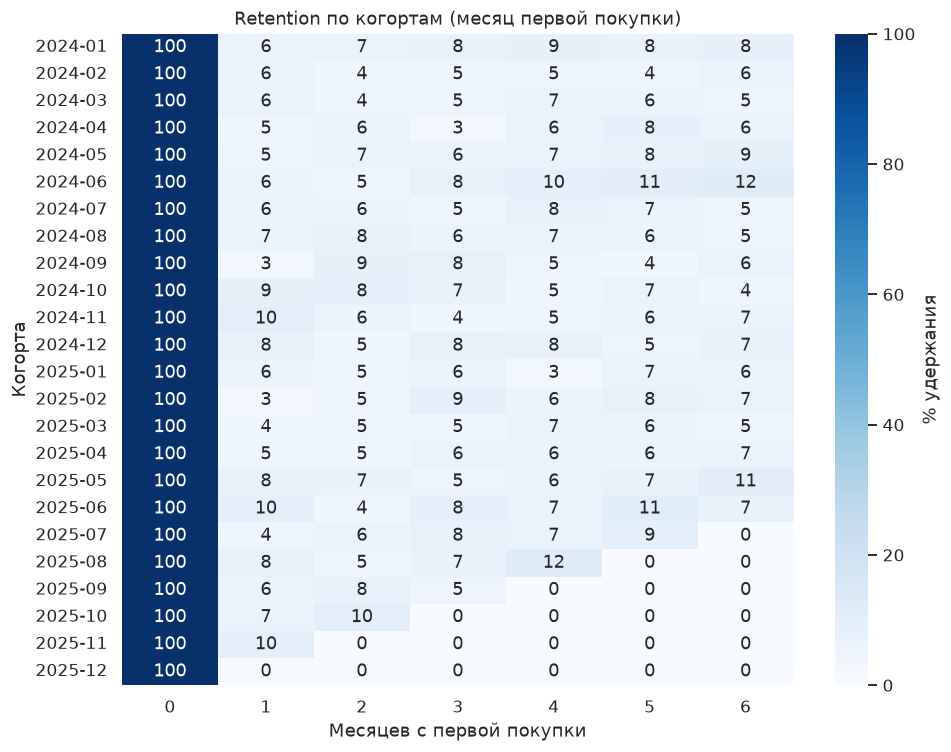

In [6]:
cohort_base = orders_customers.copy()
cohort_base["order_month"] = cohort_base["date"].dt.to_period("M")
cohort_base["cohort_month"] = cohort_base.groupby("customer_id")["order_month"].transform("min")
cohort_base["month_offset"] = (
    (cohort_base["order_month"] - cohort_base["cohort_month"]).apply(lambda x: x.n)
)

cohort_pivot = (
    cohort_base[cohort_base["month_offset"].between(0, 6)]
    .groupby(["cohort_month", "month_offset"])["customer_id"].nunique()
    .unstack(fill_value=0)
)
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% удержания"}, ax=ax)
ax.set_title("Retention по когортам (месяц первой покупки)")
ax.set_xlabel("Месяцев с первой покупки")
ax.set_ylabel("Когорта")
plt.tight_layout()
plt.savefig(FIG_DIR / "cohort_retention.png")
plt.show()

## 5. Маркетинговые каналы: расходы, выручка, ROAS

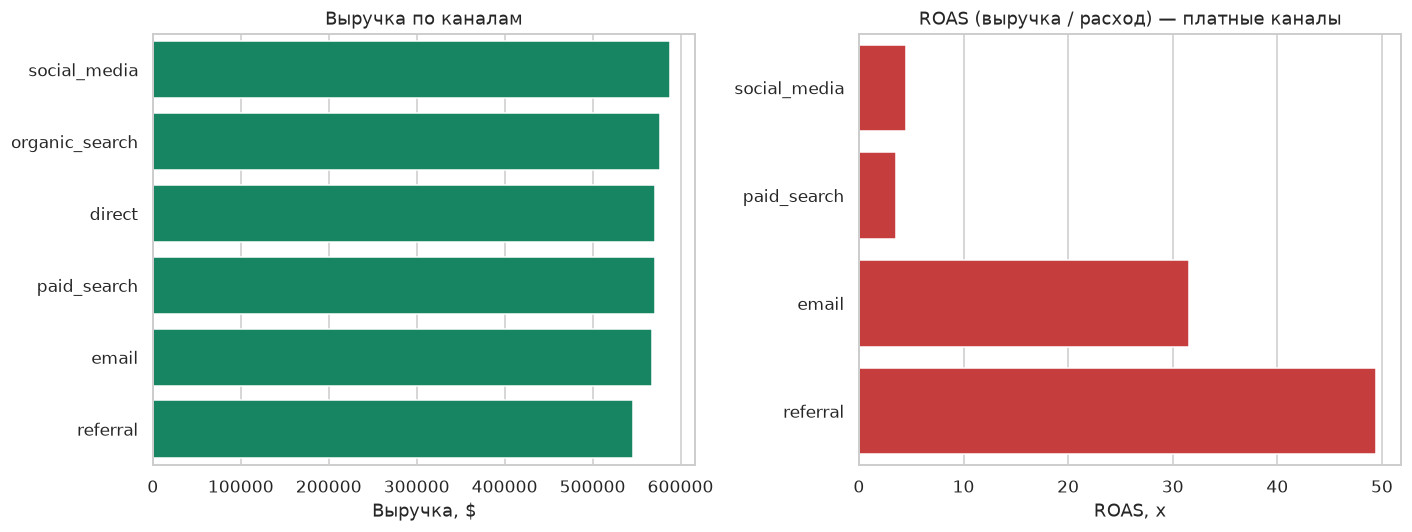

,channel_name,total_revenue,total_spend,roas
5,social_media,"587,461.39","130,742.95",4.49
2,organic_search,"576,091.65",0.00,None
0,direct,"571,372.69",0.00,None
3,paid_search,"570,984.34","160,581.82",3.56
1,email,"567,430.65","18,000.59",31.52
4,referral,"545,489.60","11,044.76",49.39


In [7]:
spend = q('''
    SELECT ch.channel_name, SUM(m.spend) AS total_spend
    FROM fact_marketing_spend m JOIN dim_channel ch ON m.channel_id = ch.channel_id
    GROUP BY ch.channel_name
''')
revenue_ch = q('''
    SELECT ch.channel_name, SUM(f.line_revenue) AS total_revenue
    FROM fact_orders f JOIN dim_channel ch ON f.channel_id = ch.channel_id
    WHERE f.order_status = 'completed'
    GROUP BY ch.channel_name
''')

channel_perf = revenue_ch.merge(spend, on="channel_name", how="left").fillna(0)
channel_perf["roas"] = (channel_perf["total_revenue"] / channel_perf["total_spend"]).replace([float("inf")], None)
channel_perf = channel_perf.sort_values("total_revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=channel_perf, y="channel_name", x="total_revenue", ax=axes[0], color="#059669")
axes[0].set_title("Выручка по каналам")
axes[0].set_xlabel("Выручка, $")
axes[0].set_ylabel("")

paid = channel_perf[channel_perf["total_spend"] > 0]
sns.barplot(data=paid, y="channel_name", x="roas", ax=axes[1], color="#dc2626")
axes[1].set_title("ROAS (выручка / расход) — платные каналы")
axes[1].set_xlabel("ROAS, x")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "channel_performance.png")
plt.show()

channel_perf

## Ключевые выводы (для README / резюме)

Итоговые формулировки — см. `README.md`, раздел "Ключевые инсайты".
Здесь фиксируются сырые цифры, на которые они опираются:

In [8]:
summary = {
    "total_revenue": round(monthly["revenue"].sum(), 2),
    "total_orders": int(monthly["orders_count"].sum()),
    "avg_order_value": round(monthly["revenue"].sum() / monthly["orders_count"].sum(), 2),
    "top_category": category_revenue.iloc[0]["category"],
    "champions_revenue_share_pct": float(seg_summary.loc["Champions", "revenue_share_pct"]) if "Champions" in seg_summary.index else None,
    "month1_retention_pct": float(retention[1].mean().round(1)),
    "best_roas_channel": paid.sort_values("roas", ascending=False).iloc[0]["channel_name"],
}
summary

{'total_revenue': np.float64(3418830.32),
 'total_orders': 13691,
 'avg_order_value': np.float64(249.71),
 'top_category': 'Accessories',
 'champions_revenue_share_pct': 51.2,
 'month1_retention_pct': 6.1,
 'best_roas_channel': 'referral'}